## Prerequisite

In [1]:
!uv pip install pygraphviz

Using Python 3.11.13 environment at: /home/maelicneau/miniconda3/envs/sgg_benchmark
Audited 1 package in 1ms


## Load model (ONNX or Pytorch)

In [2]:
import sys, os

# Make sure demo_model is importable when running from any cwd
sys.path.insert(0, os.path.dirname(os.path.abspath("demo_model.py")))

from demo_model import SGG_Model
import cv2
import matplotlib.pyplot as plt
import numpy as np

# ── ✏️  Edit these three paths ──────────────────────────────────────────────
CHECKPOINT_DIR = "../checkpoints/PSG/react++_yolo12m/yolo12m"   # folder that contains config.yml + *.pth / *.onnx
WEIGHTS_FILE   = None               # set to a filename (e.g. "model.pth" or "model.onnx") or
                                    # leave None to auto-detect the last .pth or .onnx in CHECKPOINT_DIR
SOURCE         = "./example.jpg"    # path to an image file OR a directory of images
# ────────────────────────────────────────────────────────────────────────────

# Inference thresholds
REL_CONF  = 0.1   # minimum relation confidence
BOX_CONF  = 0.4  # minimum bounding-box confidence

# Auto-detect config and weights
config_path = os.path.join(CHECKPOINT_DIR, "config.yml")
if not os.path.isfile(config_path):
    config_path = os.path.join(CHECKPOINT_DIR, "hydra_config.yaml")
    if not os.path.isfile(config_path):
        config_path = None   # ONNX models with embedded metadata don't need a config

if WEIGHTS_FILE is None:
    pth_files  = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith(".pth")])
    onnx_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.endswith(".onnx")])
    candidates = pth_files + onnx_files   # prefer .pth, fall back to .onnx
    if not candidates:
        raise FileNotFoundError(f"No .pth or .onnx file found in {CHECKPOINT_DIR}")
    WEIGHTS_FILE = candidates[-1]
    print(f"Auto-selected weights: {WEIGHTS_FILE}")

weights_path = os.path.join(CHECKPOINT_DIR, WEIGHTS_FILE)

print(f"Config  : {config_path}")
print(f"Weights : {weights_path}")
print(f"Source  : {SOURCE}")

# Load the appropriate model class based on file extension
if weights_path.endswith(".onnx"):
    from onnx_model import SGG_ONNX_Model
    model = SGG_ONNX_Model(config_path, weights_path, rel_conf=REL_CONF, box_conf=BOX_CONF, show_fps=False)
else:
    model = SGG_Model(config_path, weights_path, rel_conf=REL_CONF, box_conf=BOX_CONF, show_fps=False)

print("Model loaded successfully.")


Auto-selected weights: react_pp_yolo12m.onnx
Config  : None
Weights : ../checkpoints/PSG/react++_yolo12m/yolo12m/react_pp_yolo12m.onnx
Source  : ./example.jpg
Loading ONNX model from ../checkpoints/PSG/react++_yolo12m/yolo12m/react_pp_yolo12m.onnx with CUDAExecutionProvider...
ONNX Session loaded with providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Loaded 133 object classes and 57 relation classes from ONNX metadata.
Model loaded successfully.


2026-03-10 11:23:53.545784430 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-03-10 11:23:53.545804304 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.
2026-03-10 11:23:53.545808274 [W:onnxruntime:Default, scatter_nd.h:51 ScatterNDWithAtomicReduction] ScatterND with reduction=='none' only guarantees to be correct if indices are not duplicated.


## Inference & Visualisation

In [3]:
def run_on_image(img_path):
    """Run inference on a single image and return (annotated_img, graph_img)."""
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {img_path}")
    clean_img, graph = model.predict(img, visu_type='image')
    clean_img = cv2.cvtColor(clean_img, cv2.COLOR_BGR2RGB)
    if graph is not None:
        graph = cv2.cvtColor(graph, cv2.COLOR_BGR2RGB)
    return clean_img, graph


if os.path.isfile(SOURCE):
    # ── Single image ──────────────────────────────────────────────────────
    clean_img, graph = run_on_image(SOURCE)

elif os.path.isdir(SOURCE):
    # ── Directory of images ───────────────────────────────────────────────
    out_dir = os.path.join(SOURCE, "results")
    os.makedirs(out_dir, exist_ok=True)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    image_files = [f for f in sorted(os.listdir(SOURCE))
                   if os.path.splitext(f)[1].lower() in exts]

    if not image_files:
        raise FileNotFoundError(f"No images found in {SOURCE}")

    for fname in image_files:
        img_path = os.path.join(SOURCE, fname)
        result, _ = run_on_image(img_path)
        save_path = os.path.join(out_dir, f"res_{fname}")
        cv2.imwrite(save_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))
        print(f"Saved: {save_path}")

    # show last result
    clean_img, graph = run_on_image(os.path.join(SOURCE, image_files[-1]))
    print(f"Showing last image: {image_files[-1]}")

else:
    raise FileNotFoundError(f"SOURCE not found: {SOURCE}")


['person', 'dining table', 'person', 'bottle', 'person', 'person', 'person', 'chair', 'chair', 'wine glass', 'cup', 'cup', 'cup', 'wine glass', 'wine glass', 'wine glass', 'chair', 'wine glass', 'person', 'cup', 'knife', 'chair', 'tie', 'floor', 'tie', 'chair', 'chair', 'tie', 'person', 'chair']


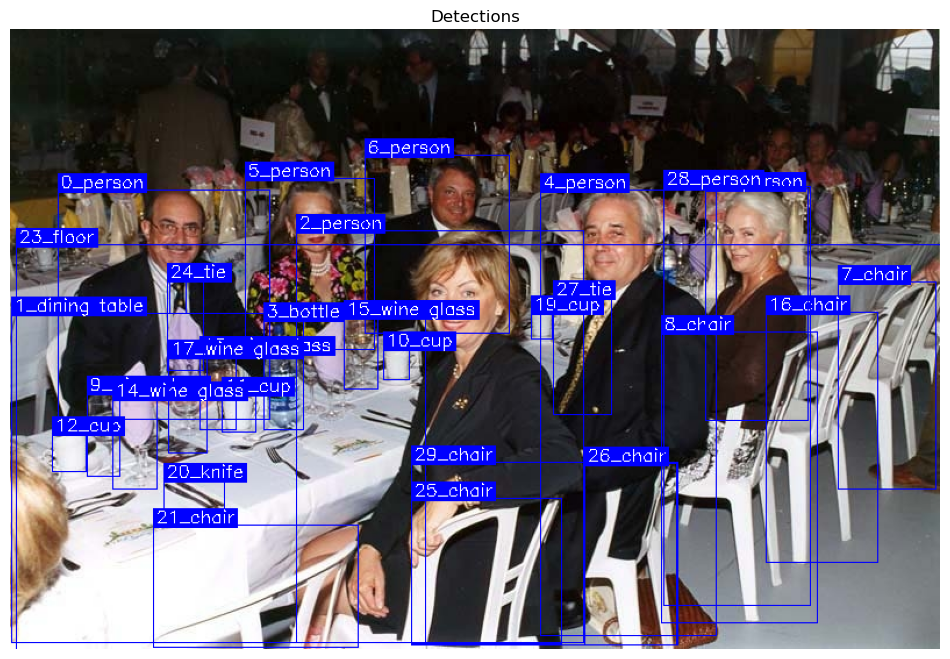

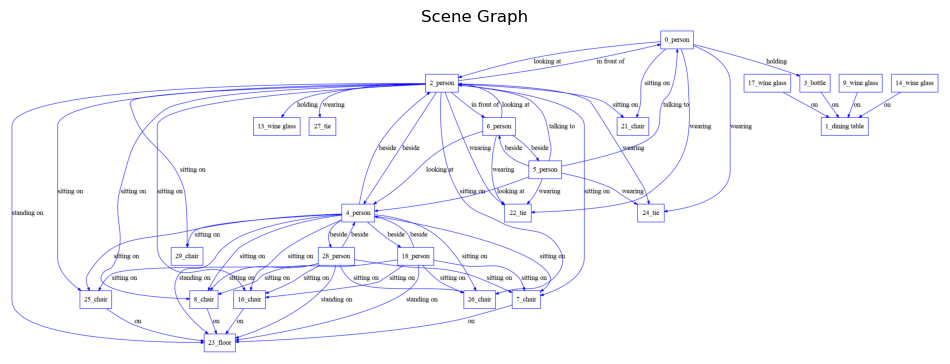

In [4]:
plt.figure(figsize=(12, 10))
plt.imshow(clean_img)
plt.title("Detections")
plt.axis('off')
plt.show()

if graph is not None:
    plt.figure(figsize=(12, 8))
    plt.imshow(graph)
    plt.title("Scene Graph")
    plt.axis('off')
    plt.show()
